In [ ]:
!pip install transformers==4.37.2

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Conv1D,  GlobalMaxPooling1D
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from transformers import BertTokenizer, TFBertModel

import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split


In [ ]:
os.environ["WANDB_API_KEY"] = "0" ## to silence warning

In [ ]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
    strategy = tf.distribute.get_strategy() # for CPU and single GPU
    print('Number of replicas:', strategy.num_replicas_in_sync)

In [ ]:
# hyperparameters
max_length = 128
batch_size = 32
dev_size = 0.25

In [ ]:
# Bert Tokenizer
model_name = "bert-base-multilingual-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/shashank_paper_2/Hindi/Hindi_Depression.csv")
train_df.head()
#train_df = pd.read_excel('/content/drive/MyDrive/paper_5/Experiment with Hindi Dataset/list_hinglish.xlsx', names = ['CM', 'Hindi', 'label'])

In [ ]:
train_df.tail()

In [ ]:
train, dev = train_test_split(train_df, test_size=dev_size, random_state=42)

In [ ]:
dev

In [ ]:
def bert_encode(data):
    tokens = tokenizer.batch_encode_plus(data, max_length=max_length, padding='max_length', truncation=True)

    return tf.constant(tokens['input_ids'])

In [ ]:
train_encoded = bert_encode(train.text)
dev_encoded = bert_encode(dev.text)


train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((train_encoded, train.label))
    .shuffle(100)
    .batch(batch_size)
)

dev_dataset = (
    tf.data.Dataset
    .from_tensor_slices((dev_encoded, dev.label))
    .shuffle(100)
    .batch(batch_size)
)

In [ ]:
def bert_tweets_model():
    # Load the BERT model
    bert_encoder = TFBertModel.from_pretrained(model_name)

    # Define input layer for BERT
    input_word_ids = tf.keras.Input(shape=(max_length,), dtype=tf.int32, name="input_ids")

    # Get BERT embeddings
    bert_output = bert_encoder(input_word_ids)[0]  # Extract BERT embeddings

    # Add multiple 1D convolutional layers with different kernel sizes
    conv1 = tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu')(bert_output)
    conv2 = tf.keras.layers.Conv1D(filters=64, kernel_size=5, activation='relu')(bert_output)
    conv3 = tf.keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu')(bert_output)

    # Concatenate the output of all convolutional layers
    concat_layer = tf.keras.layers.Concatenate(axis=1)([conv1, conv2, conv3])

    # Add global max pooling layer
    pooled_layer = tf.keras.layers.GlobalMaxPooling1D()(concat_layer)

    # Add output layer
    output = tf.keras.layers.Dense(1, activation='sigmoid')(pooled_layer)

    # Define the model
    model = tf.keras.Model(inputs=input_word_ids, outputs=output)

    return model

# Initialize the model
with strategy.scope():
    model = bert_tweets_model()
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(loss='binary_crossentropy', optimizer=adam_optimizer, metrics=['accuracy'])

# Print model summary
model.summary()



In [ ]:
train_dataset

In [ ]:
#from keras.utils.vis_utils import plot_model
with strategy.scope():
    model = bert_tweets_model()
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(loss='binary_crossentropy',optimizer=adam_optimizer,metrics=['accuracy'])

    model.summary()
    #plot_model(model=model, show_shapes=True)


In [ ]:
history = model.fit(
    train_dataset,
    batch_size=batch_size,
    epochs=3,
    validation_data=dev_dataset,
    verbose=2)
    #callbacks=[tf.keras.callbacks.EarlyStopping(
    #            patience=6,
    #            min_delta=0.05,
    #            baseline=0.7,
    #            mode='min',
    #            monitor='val_accuracy',
    #            restore_best_weights=True,
    #            verbose=1)
    #          ])

In [ ]:
import matplotlib.pyplot as plt

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [ ]:
test, val = train_test_split(dev, test_size=dev_size, random_state=42)

In [ ]:
dev.shape

In [ ]:
test.head()

In [ ]:
test_encoded = bert_encode(dev.text)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(test_encoded)
    .batch(batch_size)
)

predicted_tweets = model.predict(test_dataset, batch_size=batch_size)
predicted_tweets_binary = tf.cast(tf.round(predicted_tweets), tf.int32).numpy().flatten()
print(predicted_tweets_binary)
#my_submission = pd.DataFrame({'id': dev.id, 'label': predicted_tweets_binary})
#my_submission.to_csv('my_submission.csv', index=False)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn import metrics


In [ ]:
print("Bert+CNN")
print("Accuracy score =", accuracy_score(dev['label'], predicted_tweets_binary))
print(metrics.classification_report(dev['label'], predicted_tweets_binary))


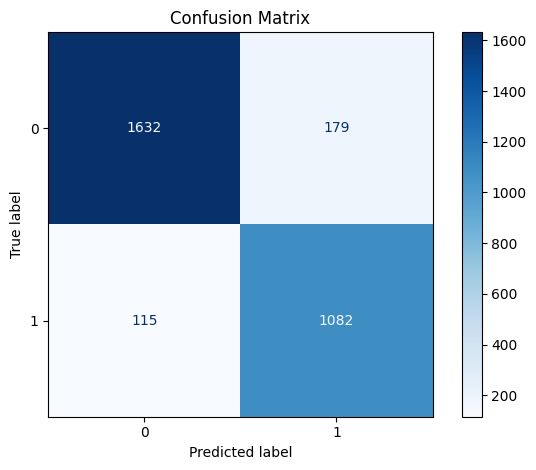

<Figure size 640x480 with 0 Axes>

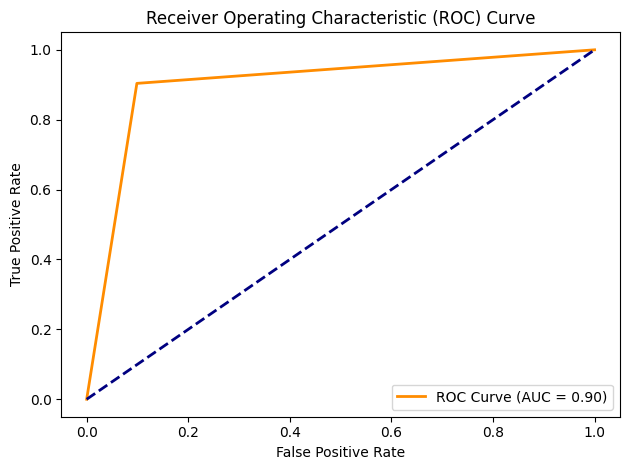

<Figure size 640x480 with 0 Axes>

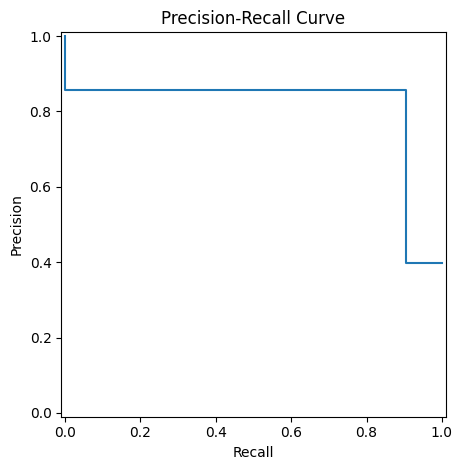

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
)

# Sample true labels and predicted probabilities
# Replace these with your actual data
#y_true = np.array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0])
#y_pred_proba = np.array([0.1, 0.8, 0.9, 0.3, 0.7, 0.2, 0.85, 0.9, 0.4, 0.5])
#y_pred = (y_pred_proba >= 0.5).astype(int)

# Plot Confusion Matrix
cm = confusion_matrix(dev['label'], predicted_tweets_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
plt.savefig('/content/drive/MyDrive/shashank_paper_2/Hindi//confusion_h_bert-cnn.pdf', format="pdf")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(dev['label'], predicted_tweets_binary)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.tight_layout()
plt.legend(loc="lower right")
plt.show()
plt.savefig('/content/drive/MyDrive/shashank_paper_2/Hindi//roc_h_bert-cnn.pdf', format="pdf")

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(dev['label'], predicted_tweets_binary)
pr_disp = PrecisionRecallDisplay(precision=precision, recall=recall)
pr_disp.plot()
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()
plt.savefig('/content/drive/MyDrive/shashank_paper_2/Hindi//pr_h_bert-cnn.pdf', format="pdf")


In [ ]:
# -*- coding: utf-8 -*-
"""
Optimized Dynamic Gating Network with BERT, CNN, BiLSTM, LSTM-A (PyTorch)
Reduced MAX_LENGTH to 32, smaller hidden sizes, larger batch size.
"""

# ------------------------------
# 0. Install required packages (if needed)
# ------------------------------
!pip install transformers scikit-learn matplotlib pandas

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel

# Use cuDNN autotuner for faster convolutions
torch.backends.cudnn.benchmark = True

# ------------------------------
# 1. Hyperparameters (optimized)
# ------------------------------
MAX_LENGTH = 32          # max sentence length is ~30 words, reduced from 128
BATCH_SIZE = 64          # increased from 32 (GPU memory allows)
DEV_SIZE = 0.25
EPOCHS = 3
LEARNING_RATE = 1e-5
BRANCH_OUTPUT_DIM = 32   # reduced from 64
CNN_FILTERS = 32         # reduced from 64
LSTM_HIDDEN = 32         # reduced from 64

# ------------------------------
# 2. Device (GPU preferred)
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ------------------------------
# 3. Load data
# ------------------------------
DATA_PATH = "/content/drive/MyDrive/shashank_paper_2/Hindi/Hindi_Depression.csv"
train_df = pd.read_csv(DATA_PATH)
train, dev = train_test_split(train_df, test_size=DEV_SIZE, random_state=42)

# ------------------------------
# 4. BERT Tokenizer and Dataset
# ------------------------------
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-uncased")

def bert_encode(texts):
    # Ensure texts are strings, replace NaN
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    texts = [str(t) if pd.notna(t) else "" for t in texts]
    return tokenizer(
        texts,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

class HindiDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = [str(t) if pd.notna(t) else "" for t in texts]
        self.labels = labels
        self.encodings = bert_encode(self.texts)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

train_dataset = HindiDataset(train.text.values, train.label.values)
dev_dataset = HindiDataset(dev.text.values, dev.label.values)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ------------------------------
# 5. Define the Model (with reduced dimensions)
# ------------------------------
class DynamicGatingModel(nn.Module):
    def __init__(self, bert_model_name="bert-base-multilingual-uncased", branch_dim=BRANCH_OUTPUT_DIM):
        super(DynamicGatingModel, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.bert.config.output_hidden_states = False

        # CNN with reduced filters
        self.conv1 = nn.Conv1d(in_channels=768, out_channels=CNN_FILTERS, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=768, out_channels=CNN_FILTERS, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(in_channels=768, out_channels=CNN_FILTERS, kernel_size=7, padding=3)
        self.cnn_fc = nn.Linear(CNN_FILTERS * 3, branch_dim)

        # BiLSTM with reduced hidden size
        self.lstm = nn.LSTM(input_size=768, hidden_size=LSTM_HIDDEN, batch_first=True, bidirectional=True)
        self.lstm_fc = nn.Linear(LSTM_HIDDEN * 2, branch_dim)

        # LSTM-Attention (same hidden size)
        self.lstm_att = nn.LSTM(input_size=768, hidden_size=LSTM_HIDDEN, batch_first=True, bidirectional=True)
        self.att_fc = nn.Linear(LSTM_HIDDEN * 2, 1)

        # BERT pooled
        self.pooled_fc = nn.Linear(768, branch_dim)

        # Gating network
        self.gate_fc1 = nn.Linear(4 * branch_dim, 64)
        self.gate_fc2 = nn.Linear(64, 4)

        # Classifier
        self.classifier = nn.Linear(branch_dim, 1)

    def forward(self, input_ids, attention_mask):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_outputs.last_hidden_state
        pooled_output = bert_outputs.pooler_output

        # CNN branch
        seq_perm = sequence_output.permute(0, 2, 1)
        c1 = F.relu(self.conv1(seq_perm))
        c2 = F.relu(self.conv2(seq_perm))
        c3 = F.relu(self.conv3(seq_perm))
        c1 = torch.max(c1, dim=2)[0]
        c2 = torch.max(c2, dim=2)[0]
        c3 = torch.max(c3, dim=2)[0]
        cnn_out = torch.cat([c1, c2, c3], dim=1)
        branch_cnn = F.relu(self.cnn_fc(cnn_out))

        # BiLSTM branch
        lstm_out, _ = self.lstm(sequence_output)
        lstm_pool = torch.max(lstm_out, dim=1)[0]
        branch_lstm = F.relu(self.lstm_fc(lstm_pool))

        # LSTM-Attention branch
        lstm_att_out, _ = self.lstm_att(sequence_output)
        att_scores = torch.tanh(self.att_fc(lstm_att_out))
        att_weights = F.softmax(att_scores, dim=1)
        context = torch.sum(lstm_att_out * att_weights, dim=1)
        branch_lstm_att = F.relu(self.lstm_fc(context))  # reuse linear layer

        # BERT pooled branch
        branch_pool = F.relu(self.pooled_fc(pooled_output))

        # Concatenate all branches
        all_branches = torch.cat([branch_cnn, branch_lstm, branch_lstm_att, branch_pool], dim=1)

        # Gating weights
        gate = F.relu(self.gate_fc1(all_branches))
        gate_weights = F.softmax(self.gate_fc2(gate), dim=1)

        # Weighted sum
        branch_stack = torch.stack([branch_cnn, branch_lstm, branch_lstm_att, branch_pool], dim=1)
        weighted = torch.sum(branch_stack * gate_weights.unsqueeze(-1), dim=1)

        # Output
        logits = self.classifier(weighted).squeeze(-1)
        return torch.sigmoid(logits)

# ------------------------------
# 6. Initialize model, optimizer, loss
# ------------------------------
model = DynamicGatingModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss()

# ------------------------------
# 7. Training and evaluation functions
# ------------------------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].cpu().numpy()
            preds = model(input_ids, attention_mask).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)
    return np.array(all_preds), np.array(all_labels)

# ------------------------------
# 8. Training loop
# ------------------------------
for epoch in range(EPOCHS):
    loss = train_epoch(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss:.4f}")

# ------------------------------
# 9. Evaluation
# ------------------------------
pred_probs, true_labels = evaluate(model, dev_loader)
pred_binary = (pred_probs >= 0.5).astype(int)

print("Dev Accuracy:", accuracy_score(true_labels, pred_binary))
print(classification_report(true_labels, pred_binary))

# ------------------------------
# 10. Plots
# ------------------------------
'''
cm = confusion_matrix(true_labels, pred_binary)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
'''
fpr, tpr, _ = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(true_labels, pred_probs)
plt.plot(recall, precision, marker='.', label='Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 1/3, Loss: 0.4937
